# MiniLM Benchmark: Hate & Offensive Speech Classification

In [1]:
import os 
import re
import time
import pickle

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
sns.set_palette("deep")

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, pipeline, set_seed
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
from thop import profile

device = "cuda" if torch.cuda.is_available() else "cpu"

set_seed(42)

c:\Users\Nizwa\miniconda3\envs\ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Dataset

In [2]:
ds = load_dataset("MartynaKopyta/hate_offensive_tweets")

train_ds = ds["train"].rename_column("text_cleaned", "text")
val_ds = ds["validation"].rename_column("text_cleaned", "text")
test_ds = ds["test"].rename_column("text_cleaned", "text")

train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 23541
})

In [3]:
train_ds[0]

{'text': 'RT _Dorsey: My trash is worth more than you', 'label': 2}

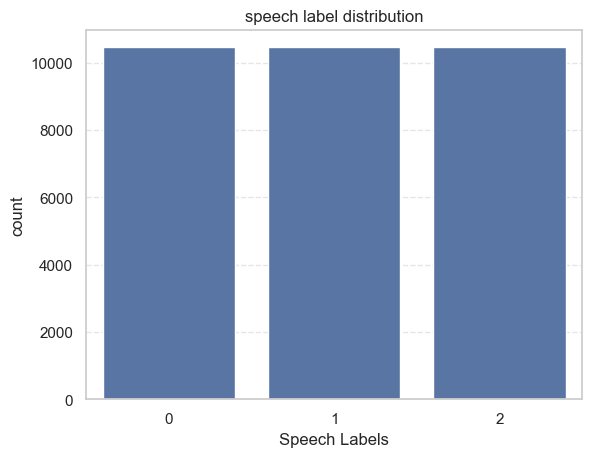

In [4]:
train = pd.DataFrame(ds["train"])
val = pd.DataFrame(ds["validation"])
test = pd.DataFrame(ds["test"])

df = pd.concat([train, val, test], ignore_index=True)

sns.countplot(data=df, x="label")
plt.title("speech label distribution")
plt.xlabel("Speech Labels")
plt.ylabel("count")
plt.grid(True, axis="y", alpha=0.5, linestyle="--")
plt.show()

In [5]:
total_labels = len(set(train_ds["label"]))
print(f"Total number of labels: {total_labels}")

Total number of labels: 3


## Load MiniLM Model

In [6]:
mini_lm = "microsoft/MiniLM-L12-H384-uncased"

mini_lm_tokenizer = AutoTokenizer.from_pretrained(mini_lm)

mini_lm_model = AutoModelForSequenceClassification.from_pretrained(
    mini_lm,
    num_labels=total_labels,
)

mini_lm_model.to(device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1291.24it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: microsoft/MiniLM-L12-H384-uncased
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 384, padding_idx=0)
      (position_embeddings): Embedding(512, 384)
      (token_type_embeddings): Embedding(2, 384)
      (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (LayerNorm): LayerNorm((384,), eps=1e-12,

In [7]:
# Total number of parameters
mini_lm_params = sum(p.numel() for p in mini_lm_model.parameters() if p.requires_grad)
print(f"MiniLM parameters: {mini_lm_params:,}")

MiniLM parameters: 33,361,155


## Minimal Preprocessing + Tokenization

In [8]:
def clean_text(text):
    # normalize whitespace
    text = str(text)
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [9]:
def tokenize(batch):
    texts = [clean_text(text) for text in batch["text"]]

    return mini_lm_tokenizer(
        texts,
        padding=False,
        truncation=True,
        max_length=256
    )

In [10]:
tokenized_train = train_ds.map(tokenize, batched=True, batch_size=1024, remove_columns=["text"])
tokenized_val = val_ds.map(tokenize, batched=True, batch_size=1024, remove_columns=["text"])
tokenized_test = test_ds.map(tokenize, batched=True, batch_size=1024, remove_columns=["text"])

Map: 100%|██████████| 1962/1962 [00:00<00:00, 45755.79 examples/s]


In [11]:
tokenized_train.set_format("torch")
tokenized_val.set_format("torch")
tokenized_test.set_format("torch")

In [12]:
tokenized_train, tokenized_val, tokenized_test

(Dataset({
     features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 23541
 }),
 Dataset({
     features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 5886
 }),
 Dataset({
     features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 1962
 }))

## Model Training (Fine Tuning)

In [13]:
def compute_metrics(pred):
    logits, labels = pred
    preds = logits.argmax(axis=-1)

    acc = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, average="macro")
    recall = recall_score(labels, preds, average="macro")
    f1 = f1_score(labels, preds, average="macro")

    return {
        "accuracy": acc, 
        "f1": f1, 
        "precision": precision, 
        "recall": recall
    }

In [14]:
LR = 2e-5
BATCH_SIZE = 16
NUM_EPOCH = 3

output_path = "./results/mini_lm"

training_args = TrainingArguments(
    output_dir=output_path,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCH,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

In [15]:
data_collator = DataCollatorWithPadding(mini_lm_tokenizer)

In [16]:
trainer = Trainer(
    model=mini_lm_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [17]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.582826,0.550408,0.760279,0.751886,0.775674,0.763893
2,0.489017,0.500409,0.777438,0.770302,0.795600,0.780753
3,0.428507,0.484311,0.784064,0.776544,0.795115,0.786658


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 13.61it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=4416, training_loss=0.5122856229975603, metrics={'train_runtime': 128.1455, 'train_samples_per_second': 551.116, 'train_steps_per_second': 34.461, 'total_flos': 453556685746710.0, 'train_loss': 0.5122856229975603, 'epoch': 3.0})

In [18]:
logs = trainer.state.log_history
df = pd.DataFrame(logs)

df.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1,eval_precision,eval_recall,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.736456,3.924586,0.000018,0.339674,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.582826,8.542772,0.000015,0.679348,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,1.000000,1472,0.550408,0.760279,0.751886,0.775674,0.763893,3.106,1895.019,118.479,NaN,NaN,NaN,NaN,NaN
3,0.533492,3.265943,0.000013,1.019022,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.495285,2.173866,0.000011,1.358696,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
clean_rows = []

last_train_loss = None

for log in trainer.state.log_history:
    if "loss" in log:
        last_train_loss = log["loss"]

    if "eval_loss" in log:
        clean_rows.append({
            "epoch": int(log.get("epoch")),
            "training_loss": last_train_loss,
            "validation_loss": log.get("eval_loss"),
            "accuracy": log.get("eval_accuracy"),
            "f1": log.get("eval_f1"),
            "precision": log.get("eval_precision"),
            "recall": log.get("eval_recall"),
        })

plot_df = pd.DataFrame(clean_rows)

plot_df

,epoch,training_loss,validation_loss,accuracy,f1,precision,recall
0,1,0.582826,0.550408,0.760279,0.751886,0.775674,0.763893
1,2,0.489017,0.500409,0.777438,0.770302,0.795600,0.780753
2,3,0.428507,0.484311,0.784064,0.776544,0.795115,0.786658


In [21]:
with open(os.path.join(output_path, "mini_lm_metrics.pkl"), "wb") as f:
    pickle.dump(plot_df, f)

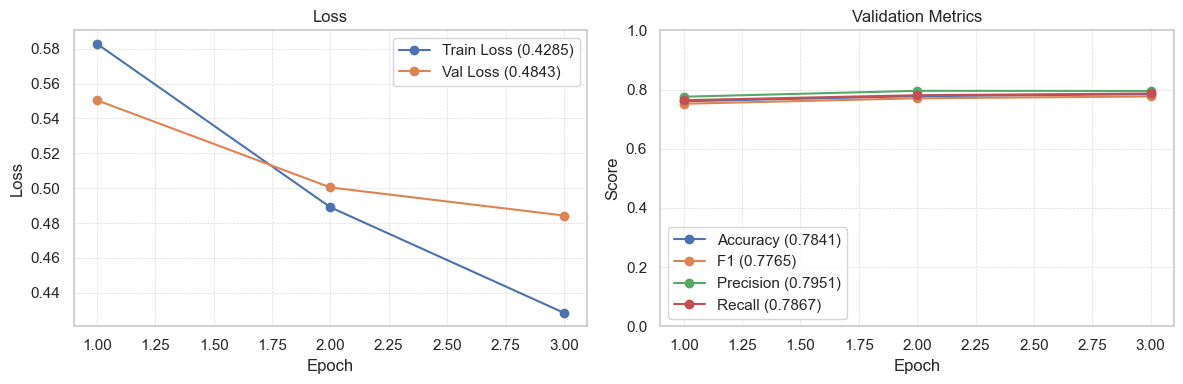

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    plot_df["epoch"],
    plot_df["training_loss"],
    marker="o",
    label=f"Train Loss ({plot_df['training_loss'].iloc[-1]:.4f})"
)
axes[0].plot(
    plot_df["epoch"],
    plot_df["validation_loss"],
    marker="o",
    label=f"Val Loss ({plot_df['validation_loss'].iloc[-1]:.4f})"
)
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
axes[0].legend()

axes[1].plot(
    plot_df["epoch"],
    plot_df["accuracy"],
    marker="o",
    label=f"Accuracy ({plot_df['accuracy'].iloc[-1]:.4f})"
)
axes[1].plot(
    plot_df["epoch"],
    plot_df["f1"],
    marker="o",
    label=f"F1 ({plot_df['f1'].iloc[-1]:.4f})"
)
axes[1].plot(
    plot_df["epoch"],
    plot_df["precision"],
    marker="o",
    label=f"Precision ({plot_df['precision'].iloc[-1]:.4f})"
)
axes[1].plot(
    plot_df["epoch"],
    plot_df["recall"],
    marker="o",
    label=f"Recall ({plot_df['recall'].iloc[-1]:.4f})"
)
axes[1].set_title("Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

In [23]:
trainer.save_model(output_path)
mini_lm_tokenizer.save_pretrained(output_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.24it/s]


('./results/mini_lm\\tokenizer_config.json',
 './results/mini_lm\\tokenizer.json')

## Model Evaluation

### 1. Performance Metrics

In [24]:
output_path = "./results/mini_lm"

tokenizer = AutoTokenizer.from_pretrained(output_path)
model = AutoModelForSequenceClassification.from_pretrained(output_path)

model.config.id2label = {
    0: "hate", 
    1: "offensive", 
    2: "neither"
}
model.config.label2id = {v:k for k,v in model.config.id2label.items()}

args = TrainingArguments(per_device_eval_batch_size=16)

loaded_trainer = Trainer(
    model=model,
    args=args,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

eval_results = loaded_trainer.evaluate(eval_dataset=tokenized_test)
eval_results

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1148.96it/s, Materializing param=classifier.weight]                                      


{'eval_loss': 0.46921172738075256,
 'eval_model_preparation_time': 0.0023,
 'eval_accuracy': 0.7961264016309888,
 'eval_f1': 0.7912297962507502,
 'eval_precision': 0.8100857779209755,
 'eval_recall': 0.7975906996812875,
 'eval_runtime': 1.1647,
 'eval_samples_per_second': 1684.579,
 'eval_steps_per_second': 105.608}

In [25]:
pred = loaded_trainer.predict(test_dataset=tokenized_test)
pred.predictions, pred.label_ids

(array([[-1.0606532, -1.5213788,  2.9023786],
        [ 2.5350428, -1.4913056, -1.3990599],
        [ 0.9798603,  2.0815382, -3.3905945],
        ...,
        [ 1.1342419,  1.9565544, -3.4450765],
        [-0.979095 , -2.1720593,  3.4915535],
        [ 1.1109009,  1.9565318, -3.4183156]],
       shape=(1962, 3), dtype=float32),
 array([2, 0, 0, ..., 1, 2, 1], shape=(1962,)))

In [26]:
pred_labels = np.argmax(pred.predictions, axis=1)
pred_labels

array([2, 0, 1, ..., 1, 2, 1], shape=(1962,))

In [27]:
prediction_labels = [
    model.config.id2label[label_id]
    for label_id in pred_labels
]

true_labels = [
    model.config.id2label[int(label_id)]
    for label_id in tokenized_test["label"]
]

In [28]:
y_df = pd.DataFrame({
    "predicted": prediction_labels,
    "true": true_labels,
})
y_df.head()

,predicted,true
0,neither,neither
1,hate,hate
2,offensive,hate
3,offensive,hate
4,offensive,offensive


In [29]:
cm_labels = dict(enumerate(model.config.id2label.values()))

list(cm_labels.values())

['hate', 'offensive', 'neither']

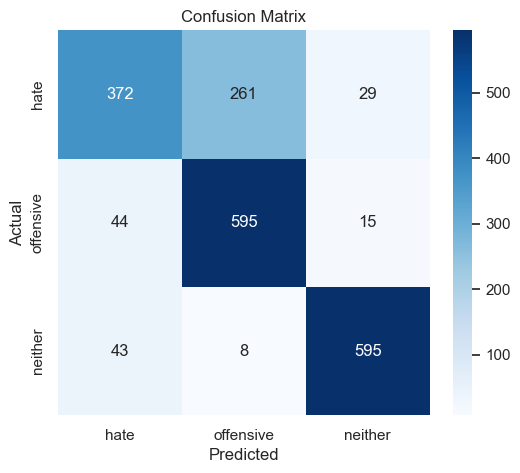

In [30]:
labels = list(cm_labels.values())

cm = confusion_matrix(
    true_labels,
    prediction_labels,
    labels=labels
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [31]:
report = classification_report(true_labels, prediction_labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.head(total_labels + 4)

,precision,recall,f1-score,support
hate,0.810458,0.561934,0.663693,662.000000
neither,0.931142,0.921053,0.926070,646.000000
offensive,0.688657,0.909786,0.783926,654.000000
accuracy,0.796126,0.796126,0.796126,0.796126
macro avg,0.810086,0.797591,0.791230,1962.000000
weighted avg,0.809594,0.796126,0.790160,1962.000000


### 2. Compute Metrics

In [32]:
def get_model_size_mb(model):
    param_size = 0

    for param in model.parameters():
        param_size += param.nelement() * param.element_size()

    buffer_size = 0

    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()

    size_mb = (param_size + buffer_size) / 1024**2

    return size_mb

In [33]:
model_size = get_model_size_mb(model)
print(f"Model size: {model_size:.2f} MB")

Model size: 127.27 MB


In [34]:
example_text = "haha i know this is a test sample, but you are so stupid"

inputs = tokenizer(
    example_text,
    return_tensors="pt",
    padding="max_length",
    truncation=True,
    max_length=128
)

inputs = {k: v.to(device) for k, v in inputs.items()}

model.eval()

macs, params = profile(
    model,
    inputs=(
        inputs["input_ids"],
        inputs["attention_mask"],
    ),
    verbose=False
)

gflops = macs * 2 / 1e9

print(f"GFLOPs: {gflops:.4f}")

GFLOPs: 5.4459


In [35]:
def measure_latency(model, tokenizer, text, device="cuda", max_length=128, warmup=10, runs=100):
    model.to(device)
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=max_length
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        for _ in range(warmup):
            _ = model(**inputs)

        if device == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()

        for _ in range(runs):
            _ = model(**inputs)

        if device == "cuda":
            torch.cuda.synchronize()

        end = time.perf_counter()

    latency_ms = ((end - start) / runs) * 1000

    return latency_ms

In [36]:
latency = measure_latency(
    model=model,
    tokenizer=tokenizer,
    text=example_text,
    device=device,
    max_length=128
)

print(f"Inference latency: {latency:.2f} ms/sample")

Inference latency: 4.24 ms/sample


# Inference Example

In [37]:
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer)

print("input text:", example_text)
classifier(example_text)

input text: haha i know this is a test sample, but you are so stupid


[{'label': 'hate', 'score': 0.9185402393341064}]